In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize']=(12,6)
plt.rcParams['font.size']=12

Payoff functions that calculates the payoff of a European call/put option at maturity

Parameters:
-----------------
S_T : float or numpy.ndarray
    Price of the underlying asset at maturity
K : float
    Strike price of the option
    
Returns:
-----------------
float or numpy.ndarray
    Payoff of the call/put

In [4]:
def call_payoff(S_T, K):
    return np.maximum(S_T - K, 0)

def put_payoff(S_T, K):
    return np.maximum(K - S_T, 0)

Similarly to the above payoff functions, the digital call/put has similar parameters 
except the output is 0 or 1 depending on the strike price compared to underlying asset price. Hence name (digital)

In [5]:
def digital_call_payoff(S_T, K):
    return (S_T > K).astype(int)

def digital_put_payoff(S_T, K):
    return (S_T < K).astype(int)

Below is a function that helps with plotting to visualize the payoff structures

In [6]:
def plot_payoff(S_T, payoffs, labels, title, filename=None):
    plt.figure(figsize=(12, 6))
    
    # Plot each payoff
    for i, payoff in enumerate(payoffs):
        plt.plot(S_T, payoff, linewidth=2.5, label=labels[i])
    
    # Add zero line for reference
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Set labels and title
    plt.xlabel('Asset Price at Maturity ($S_T$)')
    plt.ylabel('Payoff at Maturity ($V(S_T)$)')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Adjust y limits to show important features
    max_val = max([np.max(p) for p in payoffs])
    min_val = min([np.min(p) for p in payoffs])
    y_margin = 0.1 * (max_val - min_val)
    plt.ylim(min_val - y_margin, max_val + y_margin)
    
    # Save if filename provided
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()

Part (a) Basic Graphing of V(S_T) for each of the derivatives

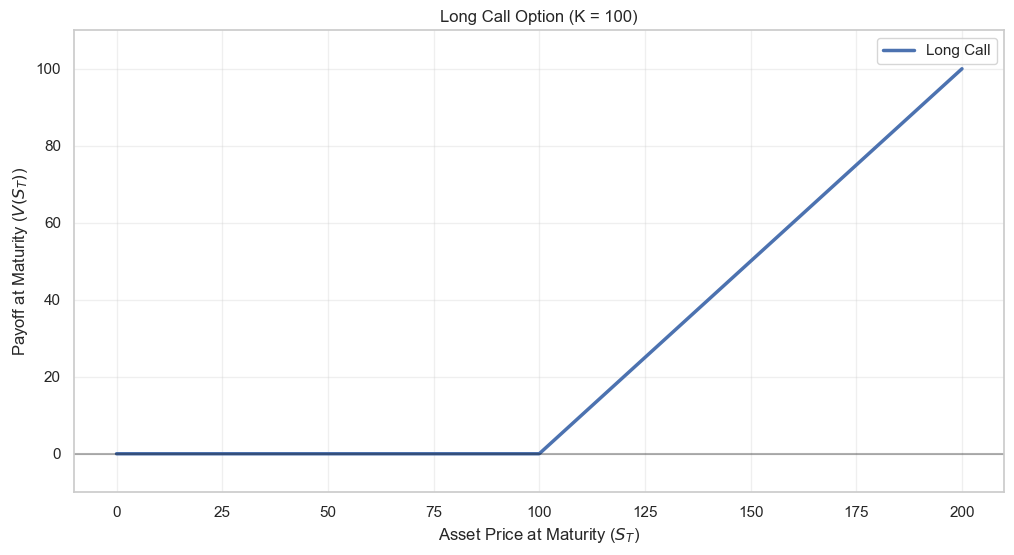

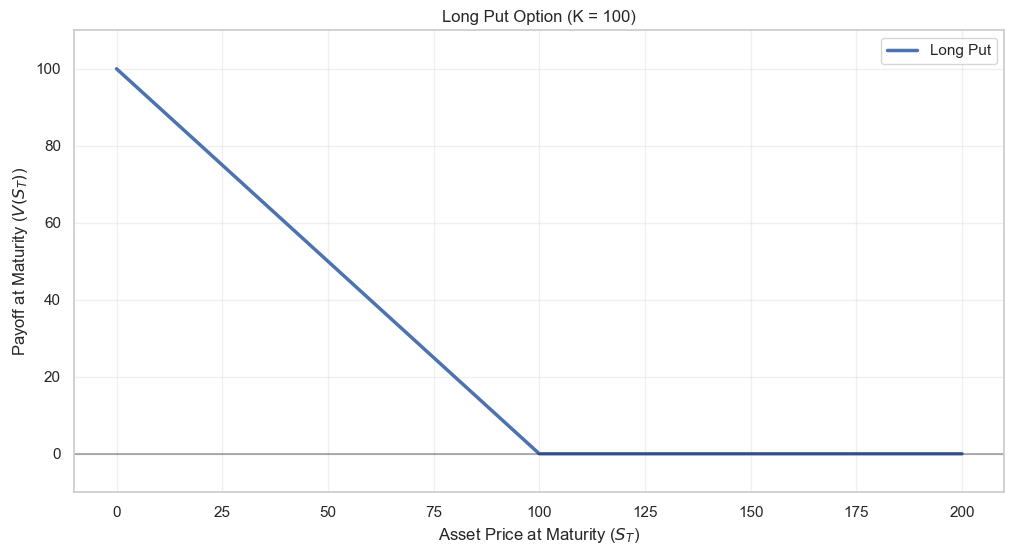

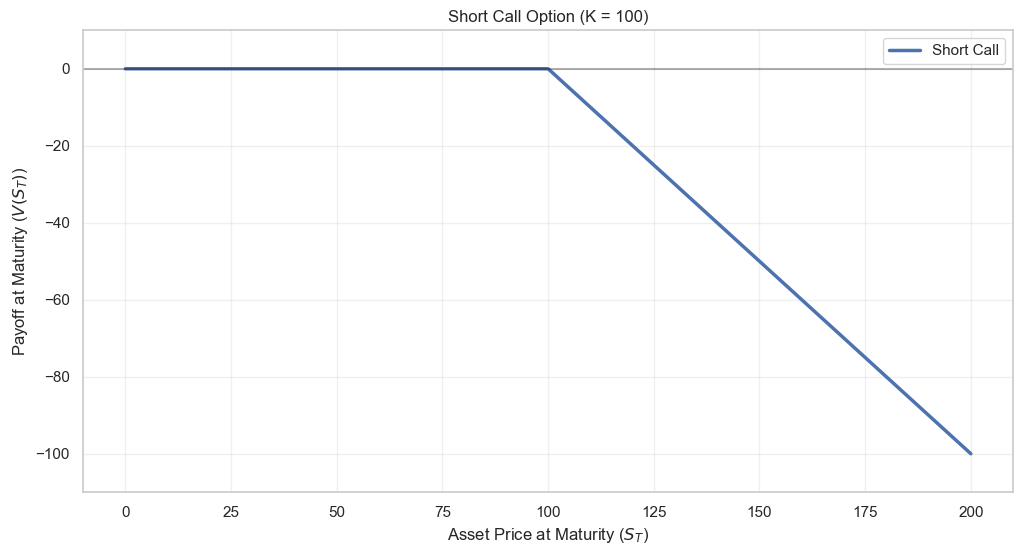

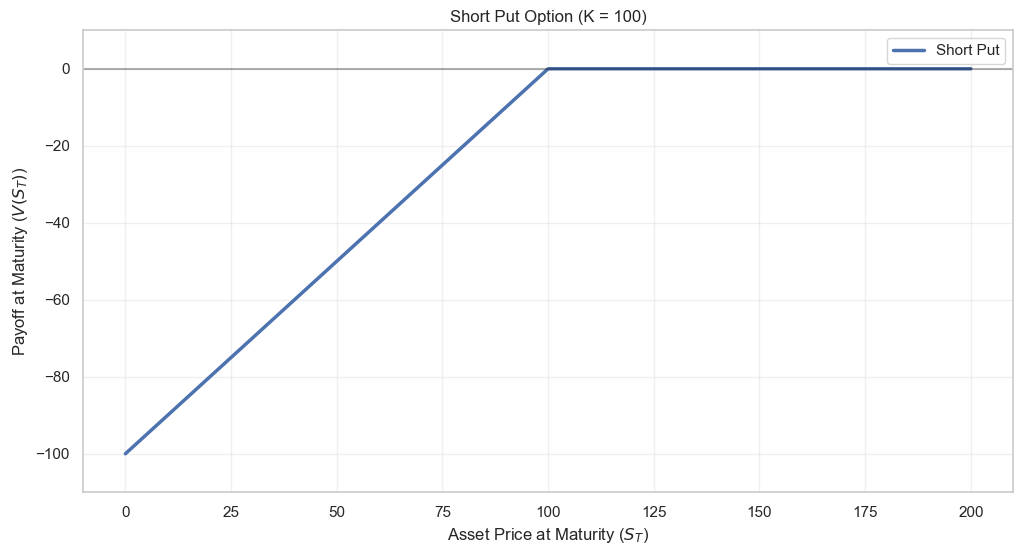

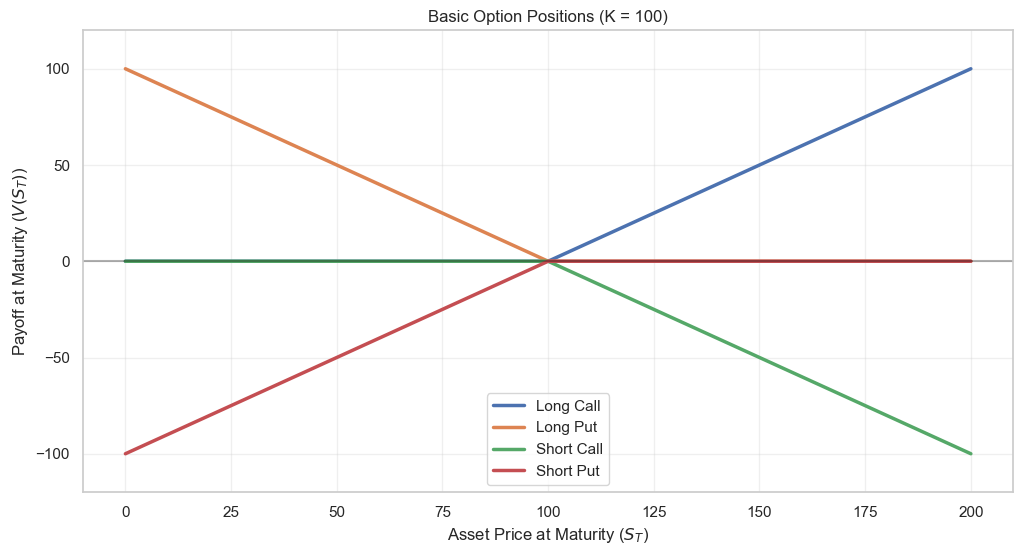

Basic Options Analysis:
Long Call: Unlimited profit potential for S_T > K, limited loss
Long Put: Limited profit potential for S_T < K, limited loss
Short Call: Limited profit potential, unlimited potential loss for S_T > K
Short Put: Limited profit potential, substantial potential loss for S_T near 0


In [7]:
# Define parameters
K = 100  # Strike price
S_T = np.linspace(0, 200, 1000)  # Range of asset prices at maturity

# Calculate payoffs for basic options
long_call = call_payoff(S_T, K)
long_put = put_payoff(S_T, K)
short_call = -call_payoff(S_T, K)
short_put = -put_payoff(S_T, K)

# Create individual plots
plot_payoff(S_T, [long_call], ['Long Call'], f'Long Call Option (K = {K})')
plot_payoff(S_T, [long_put], ['Long Put'], f'Long Put Option (K = {K})')
plot_payoff(S_T, [short_call], ['Short Call'], f'Short Call Option (K = {K})')
plot_payoff(S_T, [short_put], ['Short Put'], f'Short Put Option (K = {K})')

# Create a combined plot to compare all basic positions
plot_payoff(S_T, [long_call, long_put, short_call, short_put], 
           ['Long Call', 'Long Put', 'Short Call', 'Short Put'], 
           f'Basic Option Positions (K = {K})')

# Analysis
print("Basic Options Analysis:")
print("Long Call: Unlimited profit potential for S_T > K, limited loss")
print("Long Put: Limited profit potential for S_T < K, limited loss")
print("Short Call: Limited profit potential, unlimited potential loss for S_T > K")
print("Short Put: Limited profit potential, substantial potential loss for S_T near 0")

Part (b) Straddle

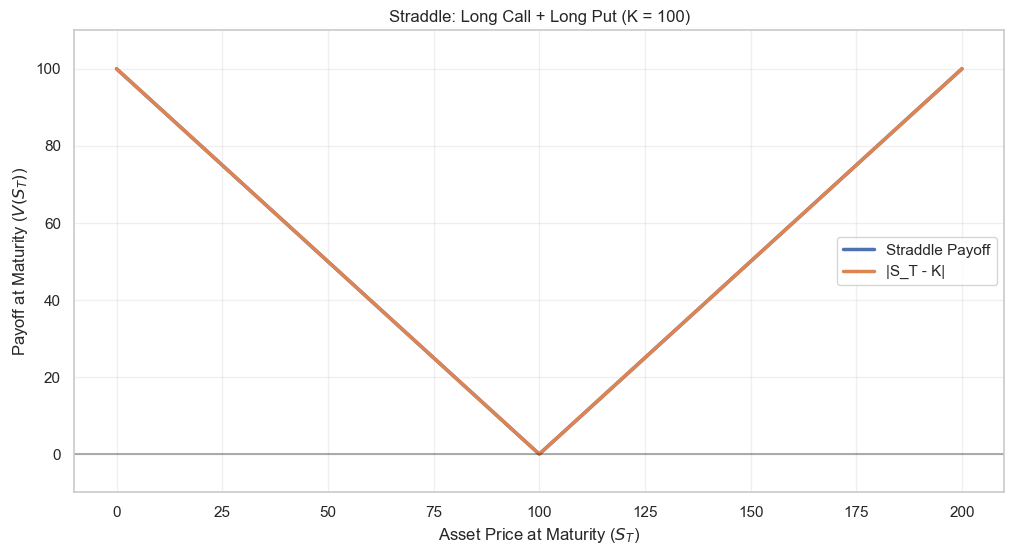

Verification that V(S_T) = |S_T - K|: True


In [8]:
# Straddle = Long Call + Long Put with same strike
K_straddle = 100
straddle_payoff = call_payoff(S_T, K_straddle) + put_payoff(S_T, K_straddle)

# Calculate the theoretical |S_T - K| payoff for verification
absolute_diff = np.abs(S_T - K_straddle)

# Plot the straddle payoff
plot_payoff(S_T, [straddle_payoff, absolute_diff], 
           ['Straddle Payoff', '|S_T - K|'], 
           f'Straddle: Long Call + Long Put (K = {K_straddle})')

# Verify that the straddle payoff equals |S_T - K|
is_equal = np.allclose(straddle_payoff, absolute_diff)
print(f"Verification that V(S_T) = |S_T - K|: {is_equal}")

Part (c) Call-Put Spread

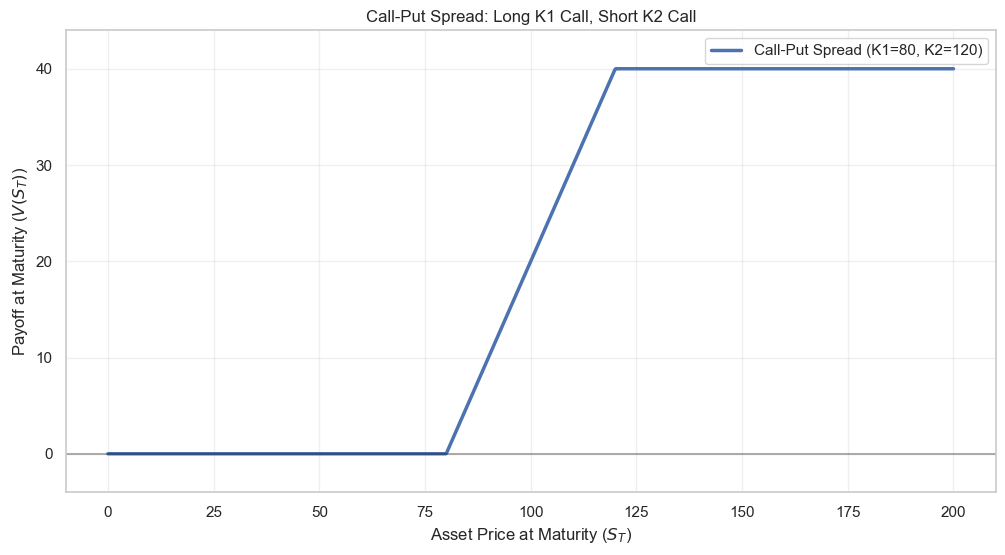


Call-Put Spread Analysis:
Maximum profit: 40 at S_T >= 120
Maximum loss: 0 at S_T <= 80
Breakeven point: 80


In [9]:
# Define parameters for call-put spread
K1_spread = 80
K2_spread = 120

# Call-put spread = Long call at K1, Short call at K2
call_put_spread = call_payoff(S_T, K1_spread) - call_payoff(S_T, K2_spread)

# Plot the call-put spread
plot_payoff(S_T, [call_put_spread], 
           [f'Call-Put Spread (K1={K1_spread}, K2={K2_spread})'], 
           f'Call-Put Spread: Long K1 Call, Short K2 Call')

# Analysis
print("\nCall-Put Spread Analysis:")
print(f"Maximum profit: {K2_spread - K1_spread} at S_T >= {K2_spread}")
print(f"Maximum loss: 0 at S_T <= {K1_spread}")
print(f"Breakeven point: {K1_spread}")

Part (d) Butterfly Spread

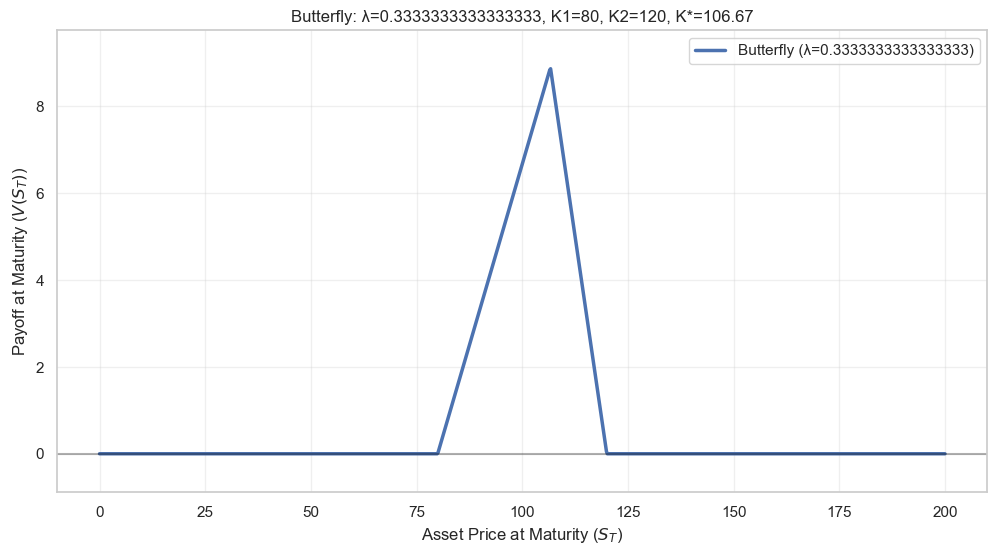


Butterfly Analysis (λ=0.3333333333333333):
K* = 106.67
Maximum payoff: 8.8622 at S_T = 106.71


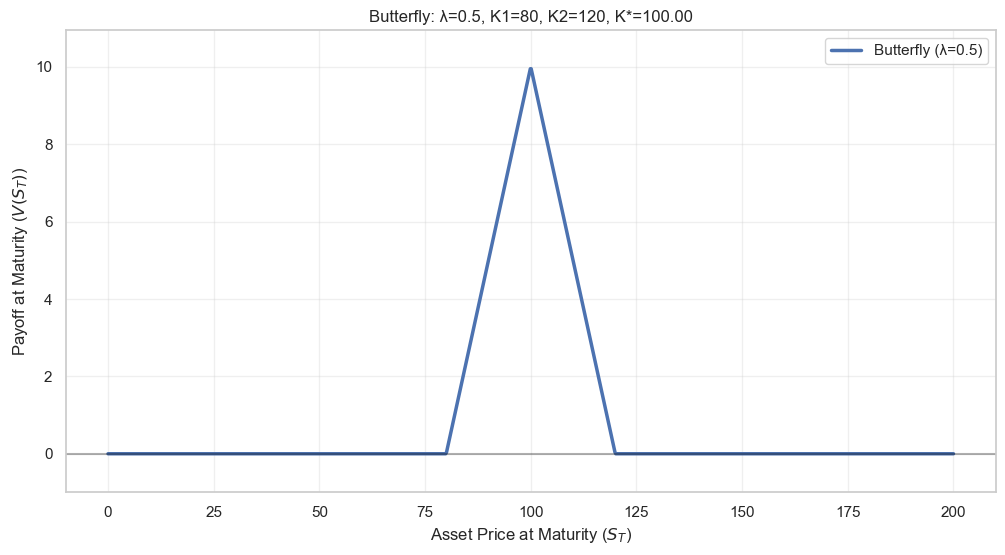


Butterfly Analysis (λ=0.5):
K* = 100.00
Maximum payoff: 9.9499 at S_T = 99.90


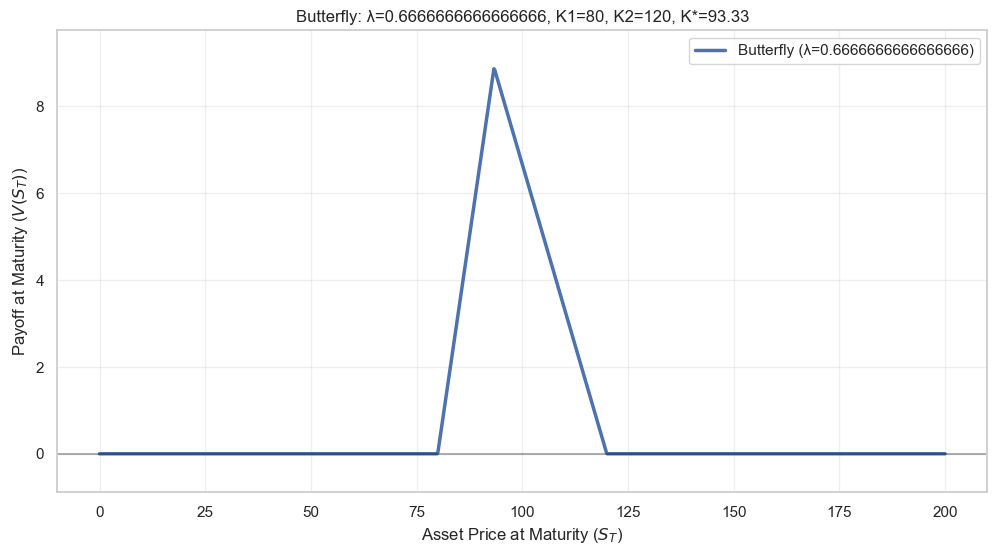


Butterfly Analysis (λ=0.6666666666666666):
K* = 93.33
Maximum payoff: 8.8622 at S_T = 93.29


In [10]:
# Define parameters for butterfly
K1_butterfly = 80
K2_butterfly = 120
lambda_values = [1/3, 1/2, 2/3]

for lambda_val in lambda_values:
    # Calculate K* = λK1 + (1-λ)K2
    K_star = lambda_val * K1_butterfly + (1 - lambda_val) * K2_butterfly
    
    # Components of butterfly:
    # Long λ calls at K1
    # Long (1-λ) calls at K2
    # Short 1 call at K*
    butterfly_payoff = (lambda_val * call_payoff(S_T, K1_butterfly) + 
                       (1 - lambda_val) * call_payoff(S_T, K2_butterfly) -
                       call_payoff(S_T, K_star))
    
    # Plot the butterfly
    plot_payoff(S_T, [butterfly_payoff], 
               [f'Butterfly (λ={lambda_val})'], 
               f'Butterfly: λ={lambda_val}, K1={K1_butterfly}, K2={K2_butterfly}, K*={K_star:.2f}')
    
    # Analysis
    max_payoff = np.max(butterfly_payoff)
    max_payoff_idx = np.argmax(butterfly_payoff)
    max_payoff_price = S_T[max_payoff_idx]
    
    print(f"\nButterfly Analysis (λ={lambda_val}):")
    print(f"K* = {K_star:.2f}")
    print(f"Maximum payoff: {max_payoff:.4f} at S_T = {max_payoff_price:.2f}")

Part (e) Call ladder

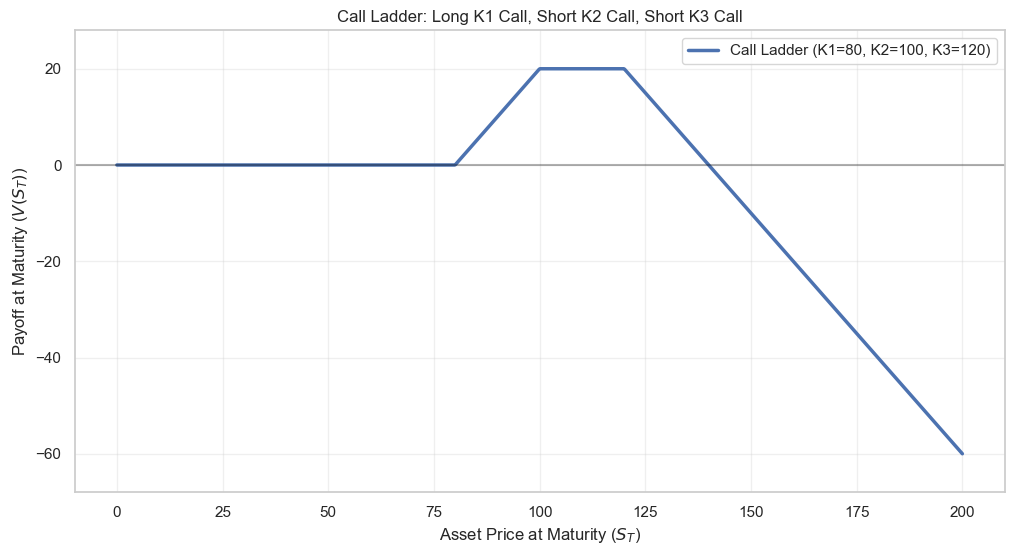


Call Ladder Analysis:
Payoff behavior:
- For S_T < 80: Payoff = 0
- For 80 < S_T < 100: Payoff increases linearly
- For 100 < S_T < 120: Payoff becomes constant
- For S_T > 120: Payoff decreases linearly without bound


In [11]:
# Define parameters for call ladder
K1_ladder = 80
K2_ladder = 100
K3_ladder = 120

# Call ladder = Long K1 call, Short K2 call, Short K3 call
call_ladder_payoff = (call_payoff(S_T, K1_ladder) - 
                     call_payoff(S_T, K2_ladder) - 
                     call_payoff(S_T, K3_ladder))

# Plot the call ladder
plot_payoff(S_T, [call_ladder_payoff], 
           [f'Call Ladder (K1={K1_ladder}, K2={K2_ladder}, K3={K3_ladder})'], 
           f'Call Ladder: Long K1 Call, Short K2 Call, Short K3 Call')

# Analysis
print("\nCall Ladder Analysis:")
print(f"Payoff behavior:")
print(f"- For S_T < {K1_ladder}: Payoff = 0")
print(f"- For {K1_ladder} < S_T < {K2_ladder}: Payoff increases linearly")
print(f"- For {K2_ladder} < S_T < {K3_ladder}: Payoff becomes constant")
print(f"- For S_T > {K3_ladder}: Payoff decreases linearly without bound")

Part (f) Digital Call Spread

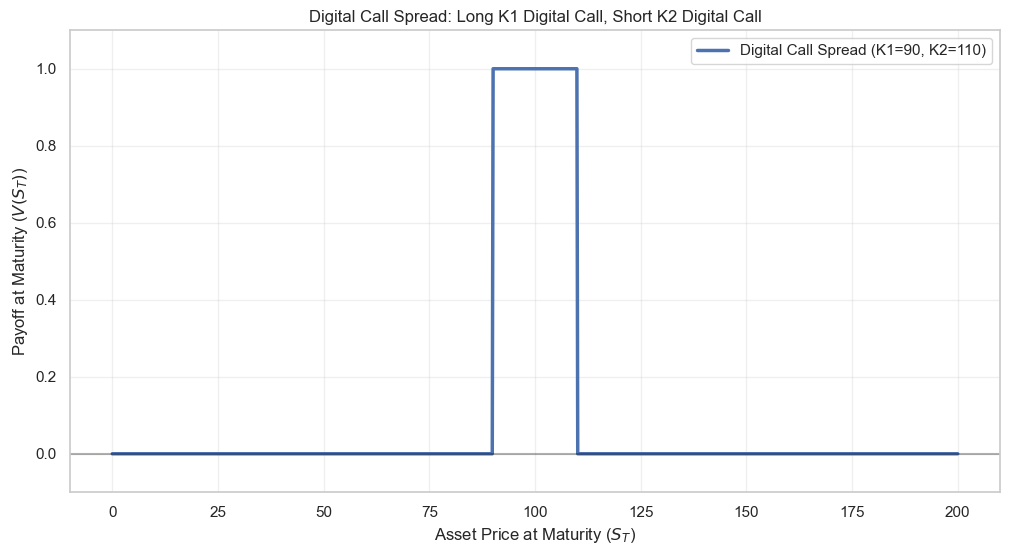


Digital Call Spread Analysis:
Payoff characteristics:
- For S_T <= 90: Payoff = 0
- For 90 < S_T <= 110: Payoff = 1
- For S_T > 110: Payoff = 0
This creates a binary or rectangular payoff profile with limited risk/reward


In [12]:
# Define parameters for digital call spread
K1_dig_spread = 90
K2_dig_spread = 110

# Digital call spread = Long digital call at K1, Short digital call at K2
dig_call_spread = digital_call_payoff(S_T, K1_dig_spread) - digital_call_payoff(S_T, K2_dig_spread)

# Plot the digital call spread
plot_payoff(S_T, [dig_call_spread], 
           [f'Digital Call Spread (K1={K1_dig_spread}, K2={K2_dig_spread})'], 
           f'Digital Call Spread: Long K1 Digital Call, Short K2 Digital Call')

# Analysis
print("\nDigital Call Spread Analysis:")
print(f"Payoff characteristics:")
print(f"- For S_T <= {K1_dig_spread}: Payoff = 0")
print(f"- For {K1_dig_spread} < S_T <= {K2_dig_spread}: Payoff = 1")
print(f"- For S_T > {K2_dig_spread}: Payoff = 0")
print("This creates a binary or rectangular payoff profile with limited risk/reward")

Overall Analysis:
-----------------
Long call: Limited Loss (premium paid)
Long put: Limited Loss (premium paid)
Short call: unlimited potential loss
Short Put: large but bounded potential loss (max = k)
Straddle: limited loss (sum of premiums)
Call-put Spread: Limited loss
Butterfly: Limited Loss
Call ladder: Unlimited potential loss for large S_T, Dangerous?
Digital Call Spread: Limited loss (exactly 1)